In [ ]:
!pip install lifelines

In [ ]:
import pandas as pd
import matplotlib
from matplotlib.offsetbox import AnchoredText
from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter
import warnings
import matplotlib.pyplot as plt

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import statsmodels.api as sm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
warnings.simplefilter('ignore')

In [ ]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
link = 'https://drive.google.com/file/d/15fJmsfxb7FGbr5PeFYBT9g6oF_SPoLQN/view?usp=share_link'
id = link.split("/")[-2]
downloaded = drive.CreateFile({'id':id})
downloaded.GetContentFile('heart_failure_clinical_records_dataset.csv')
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.shape

(299, 13)

<Axes: >

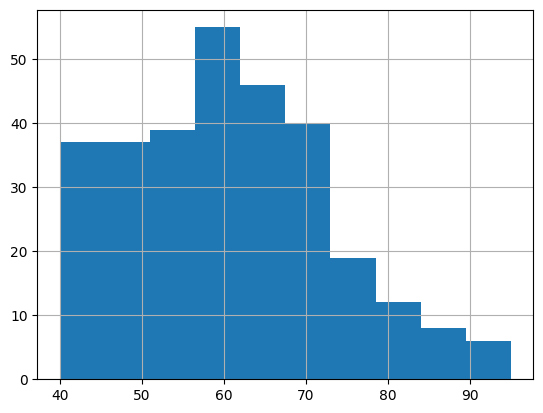

In [ ]:
# Plot histogram for age
df.age.hist()

<Axes: >

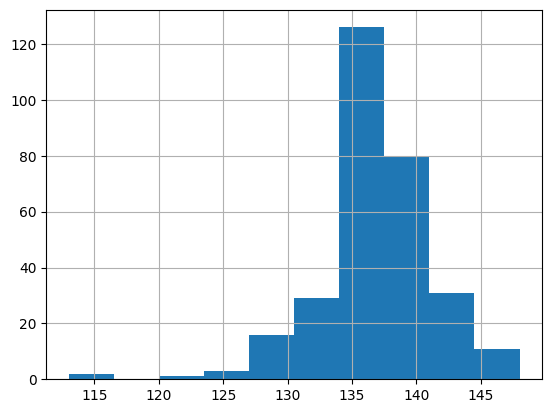

In [ ]:
# Plot histogram for serum sodium
df.serum_sodium.hist()

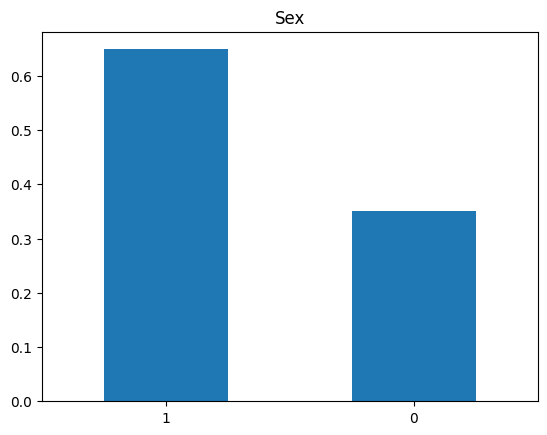

In [ ]:
df.sex.value_counts(normalize=True).plot.bar(rot = 0, title = 'Sex');

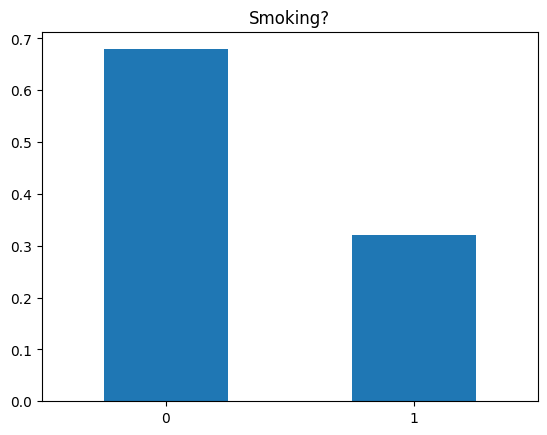

In [ ]:
df.smoking.value_counts(normalize=True).plot.bar(rot=0, title = 'Smoking?');

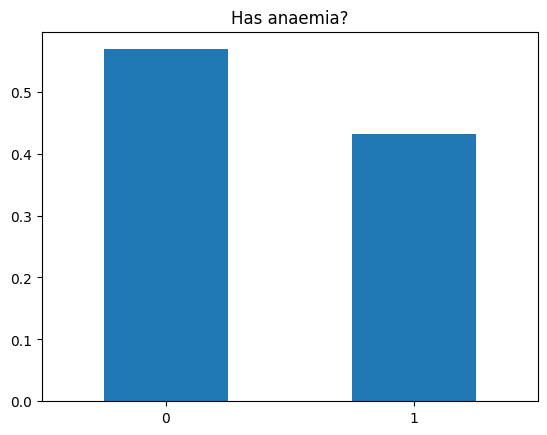

In [ ]:
df.anaemia.value_counts(normalize=True).plot.bar(rot = 0, title = 'Has anaemia?');

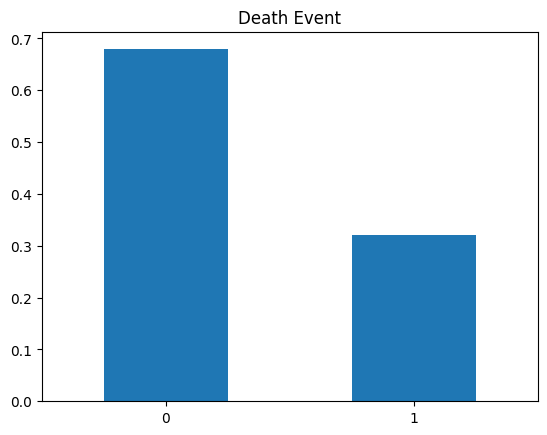

In [ ]:
df.DEATH_EVENT.value_counts(normalize=True).plot.bar(rot = 0,
                                                     title = 'Death Event');

In [ ]:
matplotlib.rcParams.update({'font.size': 16, "legend.frameon": False})


In [ ]:
E = (df.DEATH_EVENT == 1)
T = df.time
group1 = (df.anaemia == 1)
label1 = "Tem Anemia"
group2 = (df.anaemia == 0)
label2 = "Sem Anemia "

In [ ]:
def km_and_logrank(group1, group2, T, E, label1, label2):

    T1=T[group1]
    E1=E[group1]

    T2=T[group2]
    E2=E[group2]

    results=logrank_test(T1,T2,event_observed_A=E1, event_observed_B=E2)

    kmf = KaplanMeierFitter()

    ax = plt.subplot(111)
    ax = kmf.fit(T1, E1, label=f"{label1}").plot(ax=ax, ci_show=False, show_censors=True)
    ax = kmf.fit(T2, E2, label=f"{label2}").plot(ax=ax, ci_show=False, show_censors=True)
    ax.set_xlabel('Meses após o diagnóstico')
    ax.set_ylabel('Função de sobrevivência')
    plt.ylim([0, 1.1])
    anchored_text = AnchoredText("log-rank p-value: {:.3}".format(results.p_value), loc=3, frameon=False)
    ax.add_artist(anchored_text)

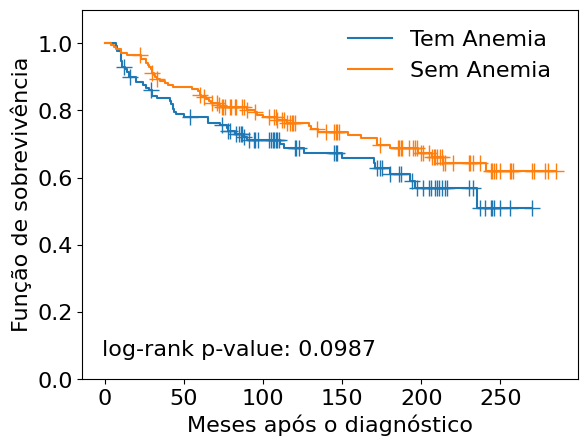

In [ ]:
km_and_logrank(group1, group2, T, E, label1, label2)

#### Exercício

Aplique uma função de sobrevivência no dataset de churn de clientes